In [12]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../')  # Add parent directory to path for imports
from datareduction import DataProposal

First we initialize the proposal using the DataProposal class. We specif the proposal name, which in general consists of a timestamp YYYY_MM and a short title. We also specify the path to the (remote) data directory, where the raw data is saved. In this example, it just points to a local folder, but in practice this will be a remote path on the UDKM measurement server.
Typing the name of the proposal object in a notebook cell returns an overview table of the scans in the proposal.

In [13]:
#prop = DataProposal("2026_04_PtCo_SL", "Remote", overwrite=True)


prop = DataProposal(
    "2026_04_PtCo_SL",
    "Remote/Data",
    spice_path="Remote/Spice",
    overwrite=True)
prop

Syncing 17/17 files from server...


100%|██████████| 17/17 [00:00<00:00, 7616.23it/s]

Sync complete.


Starting with a new spice configuration.


,scan_id,sample_name,scan_parameter,frames,delay_values,fluence_values,field_values
0,0000,SL3,Unknown,444,-1.00 ... 10.00 ps (111),11.50 °,6.00 V
1,0001,SL3,Unknown,224,-1.00 ... 10.00 ps (111),15.00 °,6.00 V
2,0002,SL3,Unknown,444,-1.00 ... 10.00 ps (111),15.00 °,6.00 V
3,0003,SL3,Unknown,444,-1.00 ... 10.00 ps (111),15.00 °,6.00 V
4,0004,SL3,Unknown,444,-1.00 ... 10.00 ps (111),15.00 °,6.00 V
5,0005,SL3,Unknown,444,-1.00 ... 10.00 ps (111),11.50 °,6.00 V
6,0006,SL3,Unknown,6660,-1.00 ... 10.00 ps (111),11.50 °,6.00 V
7,0006_processed,SL3,Unknown,3330,-1.00 ... 10.00 ps (111),11.50 °,6.00 V
8,0007,SL3,Unknown,36,-1.00 ... 10.00 ps (111),11.50 °,0.50 V
9,0008,SL3,Unknown,32,-1.00 ... 10.00 ps (111),11.50 °,0.50 V


In [14]:
prop.data

ScanAccessor: 20 scans found. Use r/p/f/b prefix + scan number (e.g. r0001).

In [15]:
init_spice = {'t0': 0}
prop.spice.seed(init_spice)
prop.spice

,t0
scan_id,
0,0.0


In [16]:
prop.process([6, 11, 12], overwrite=True)

Current spice configuration already saved locally.
Processing scan 0006...
No scan_parameter attribute found. Determining scan parameter based on number unique values...
Unique fluences: 1
Unique fields: 1
Unique delays: 111
Unique loops: 15
This is a delay scan.
Processed data saved to /home/constantin/Documents/GitUP/UDKM/Tools/trmoke-analysis/Examples/2026_04_PtCo_SL/0006_processed.nc.
Processing scan 0011...
No scan_parameter attribute found. Determining scan parameter based on number unique values...
Unique fluences: 1
Unique fields: 1
Unique delays: 111
Unique loops: 10
This is a delay scan.
Processed data saved to /home/constantin/Documents/GitUP/UDKM/Tools/trmoke-analysis/Examples/2026_04_PtCo_SL/0011_processed.nc.
Processing scan 0012...
No scan_parameter attribute found. Determining scan parameter based on number unique values...
Unique fluences: 1
Unique fields: 1
Unique delays: 226
Unique loops: 10
This is a delay scan.
Processed data saved to /home/constantin/Documents/Git

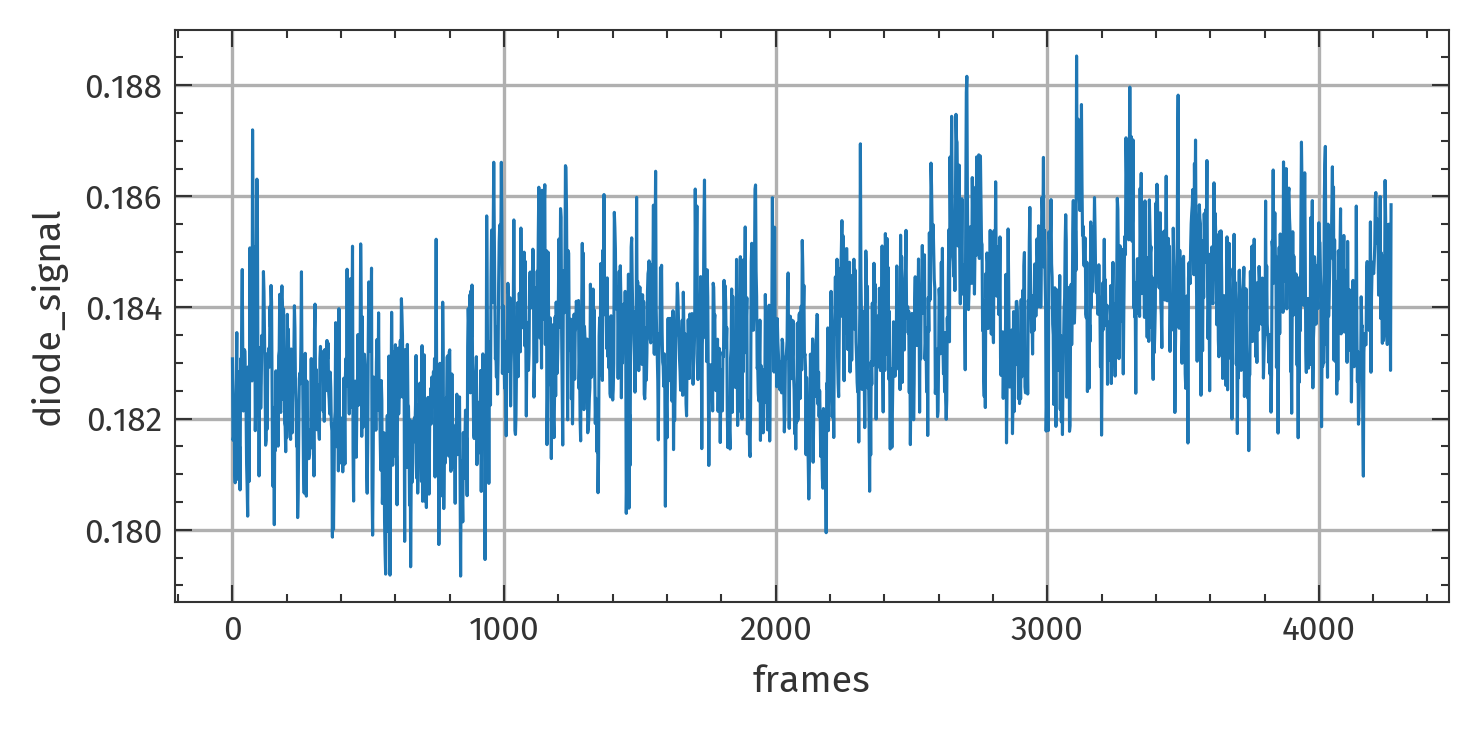

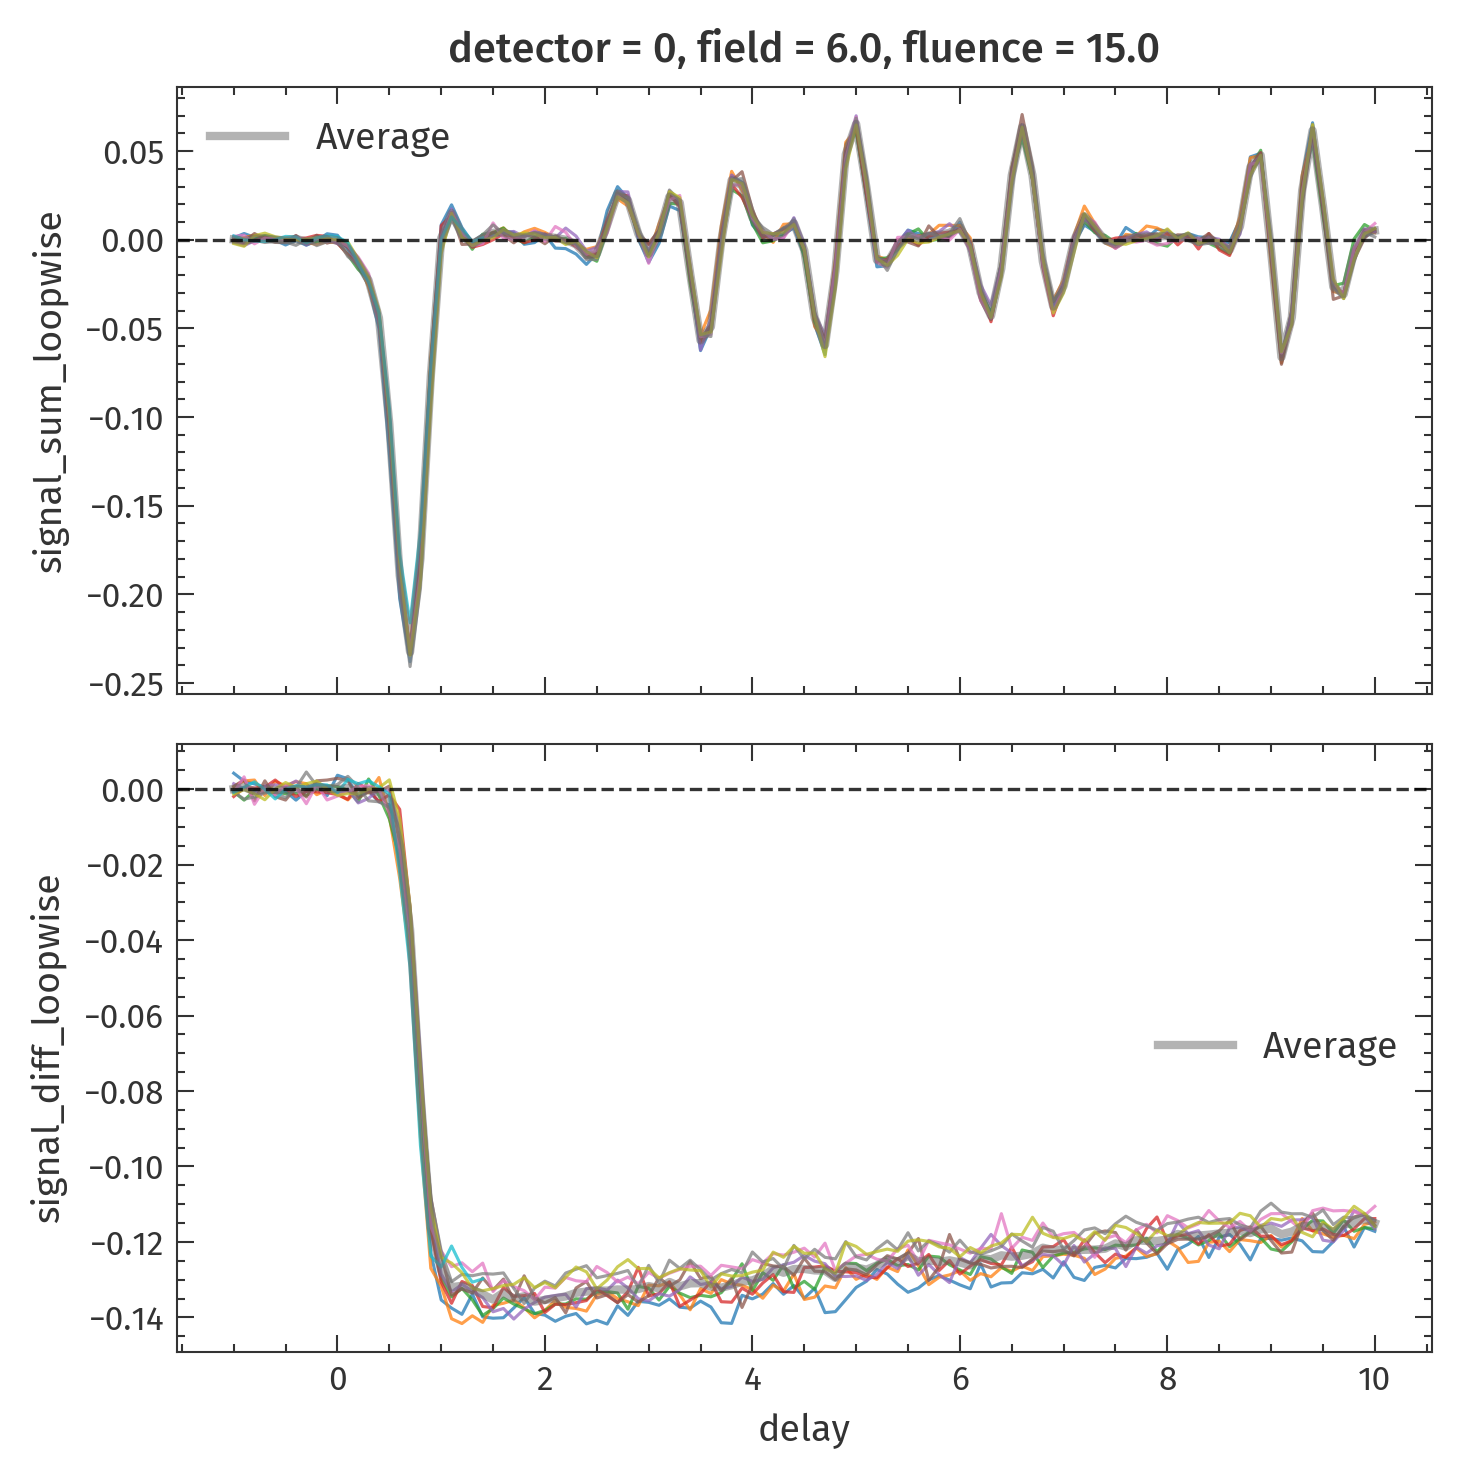

In [17]:
processed_dataset = prop.data.p0011
scan_param = processed_dataset.attrs['scan_param']
param1 = processed_dataset.attrs['param1']
param2 = processed_dataset.attrs['param2']

fig, ax = plt.subplots(dpi=300, figsize=(5, 2.5))
processed_dataset.diode_signal.plot.line(ax=ax)
ax.grid()
plt.tight_layout()
plt.show()

detector_idx = 0  # Choose which detector to plot
# Plot loopwise data for all combinations of param1 and param2
for (i, j) in np.ndindex(len(processed_dataset[param1].values), len(processed_dataset[param2].values)):
    fig, ax = plt.subplots(2, 1, dpi=300, figsize=(5, 5), sharex=True)

    # Create selection dictionary for isel
    sel_dict = {
        'detector': detector_idx,
        param1: i,
        param2: j
    }

    # Plot sum (symmetric component) - loopwise
    processed_dataset.signal_sum_loopwise.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[0], alpha=0.75)
    # Overlay average
    processed_dataset.signal_sum.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[0], color='dimgray', linewidth=2, label='Average', alpha=0.5)

    # Plot diff (antisymmetric component) - loopwise
    processed_dataset.signal_diff_loopwise.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[1], alpha=0.75)
    # Overlay average
    processed_dataset.signal_diff.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[1], color='dimgray', linewidth=2, label='Average', alpha=0.5)

    ax[1].set_title(None)
    ax[0].set_xlabel(None)
    ax[0].set_ylabel('signal_sum_loopwise')
    ax[1].set_ylabel('signal_diff_loopwise')

    ax[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)

    ax[0].legend(ncols=4)
    ax[1].legend(ncols=4)

    plt.tight_layout()
    plt.show()


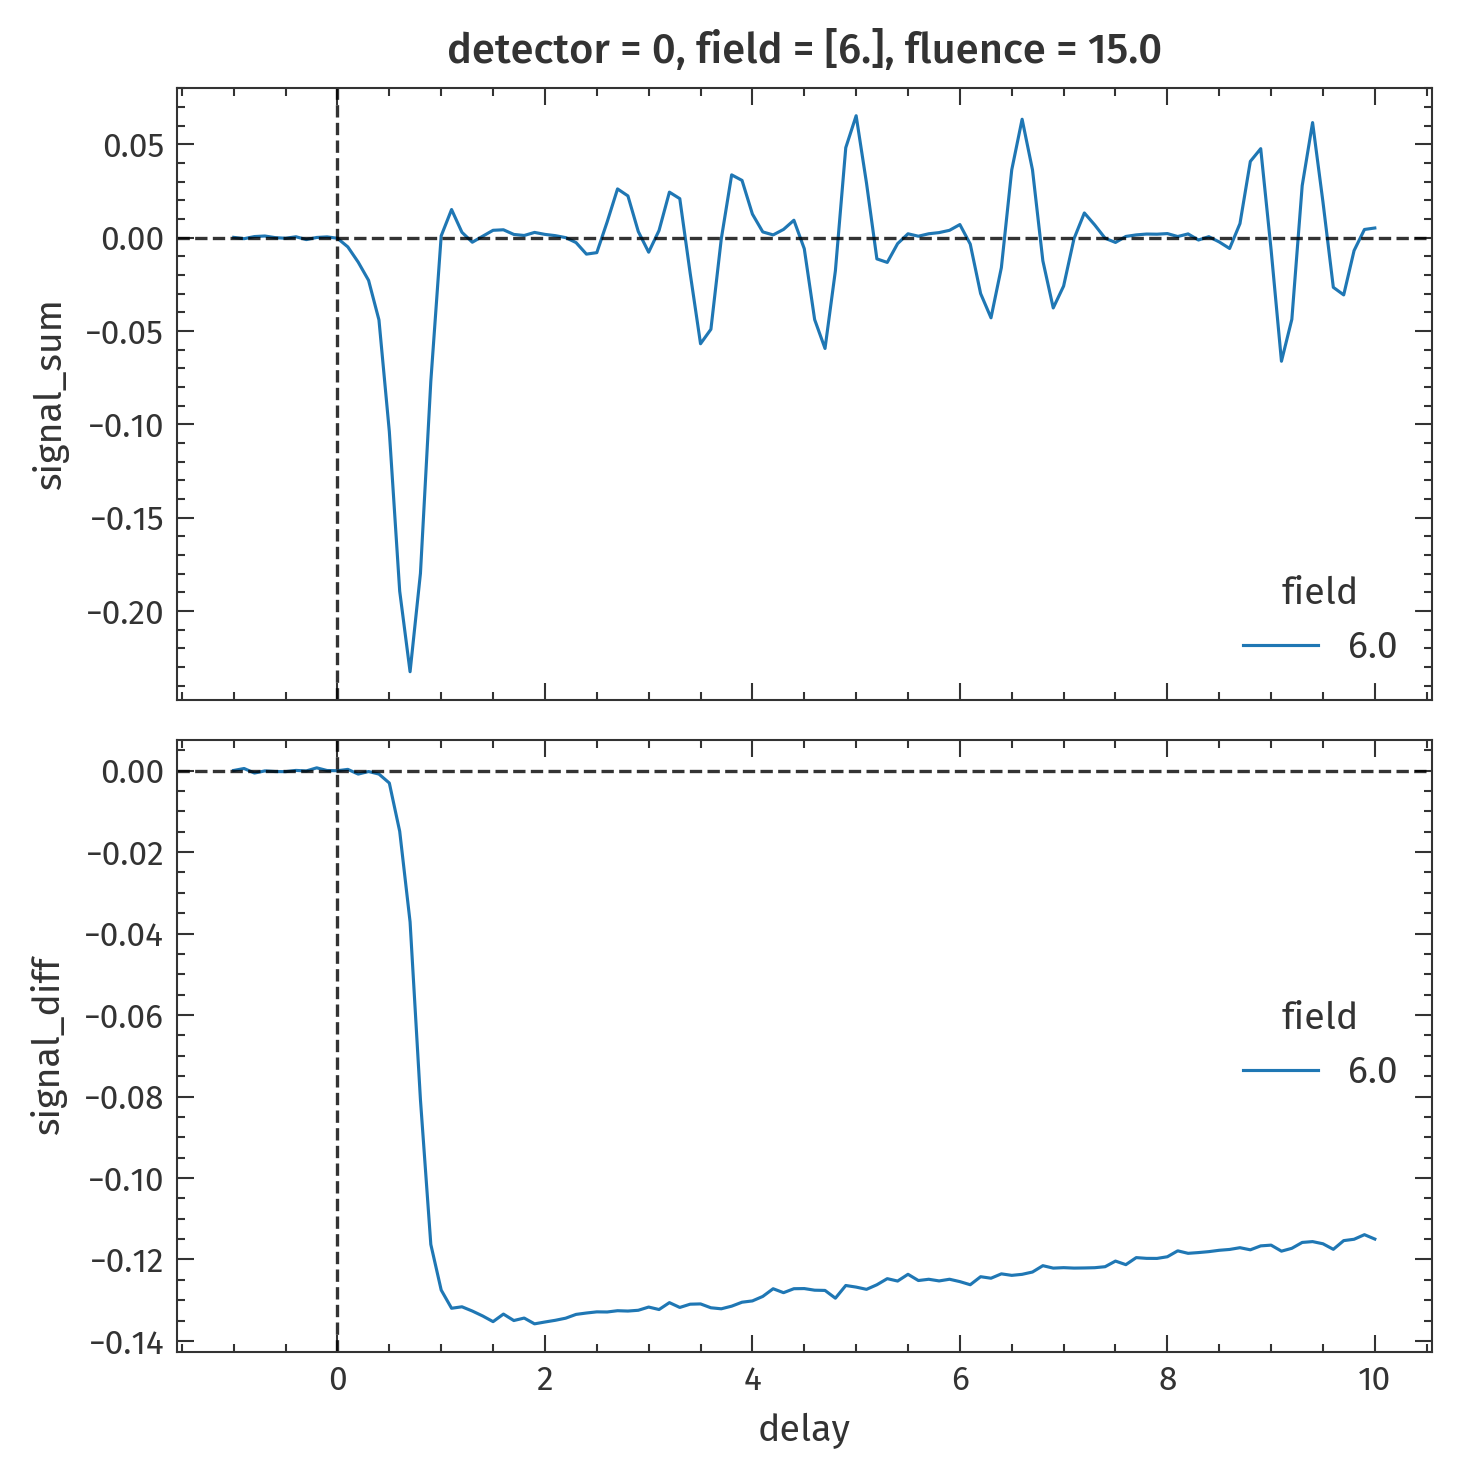

In [18]:
for param1_idx in range(len(processed_dataset[param1].values)):
    fig, ax = plt.subplots(2, 1, dpi=300, figsize=(5, 5), sharex=True)

    # Create selection dictionary
    sel_dict = {
        'detector': detector_idx,
        param1: param1_idx
    }

    # Plot sum (symmetric component)
    processed_dataset.signal_sum.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[0], add_legend=True)
    # Plot diff (antisymmetric component)
    processed_dataset.signal_diff.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[1], add_legend=True)

    ax[1].set_title(None)
    ax[0].set_xlabel(None)
    ax[0].set_ylabel('signal_sum')
    ax[1].set_ylabel('signal_diff')

    ax[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[0].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)

    plt.tight_layout()
    plt.show()

In [19]:
prop.spice.update(11, {'t0': 0.5})
prop.spice

,t0
scan_id,
0,0.0
11,0.5


In [20]:
prop.process([6, 11, 12], overwrite=True)

Spice configuration updated and saved as 6cfab30e84645d7f7c3db212780dc1456202c5b029727cab6b5a1c5db2961335.nc in local and server spice folders.
Processing scan 0006...
No scan_parameter attribute found. Determining scan parameter based on number unique values...
Unique fluences: 1
Unique fields: 1
Unique delays: 111
Unique loops: 15
This is a delay scan.
Processed data saved to /home/constantin/Documents/GitUP/UDKM/Tools/trmoke-analysis/Examples/2026_04_PtCo_SL/0006_processed.nc.
Processing scan 0011...
No scan_parameter attribute found. Determining scan parameter based on number unique values...
Unique fluences: 1
Unique fields: 1
Unique delays: 111
Unique loops: 10
This is a delay scan.
Processed data saved to /home/constantin/Documents/GitUP/UDKM/Tools/trmoke-analysis/Examples/2026_04_PtCo_SL/0011_processed.nc.
Processing scan 0012...
No scan_parameter attribute found. Determining scan parameter based on number unique values...
Unique fluences: 1
Unique fields: 1
Unique delays: 226


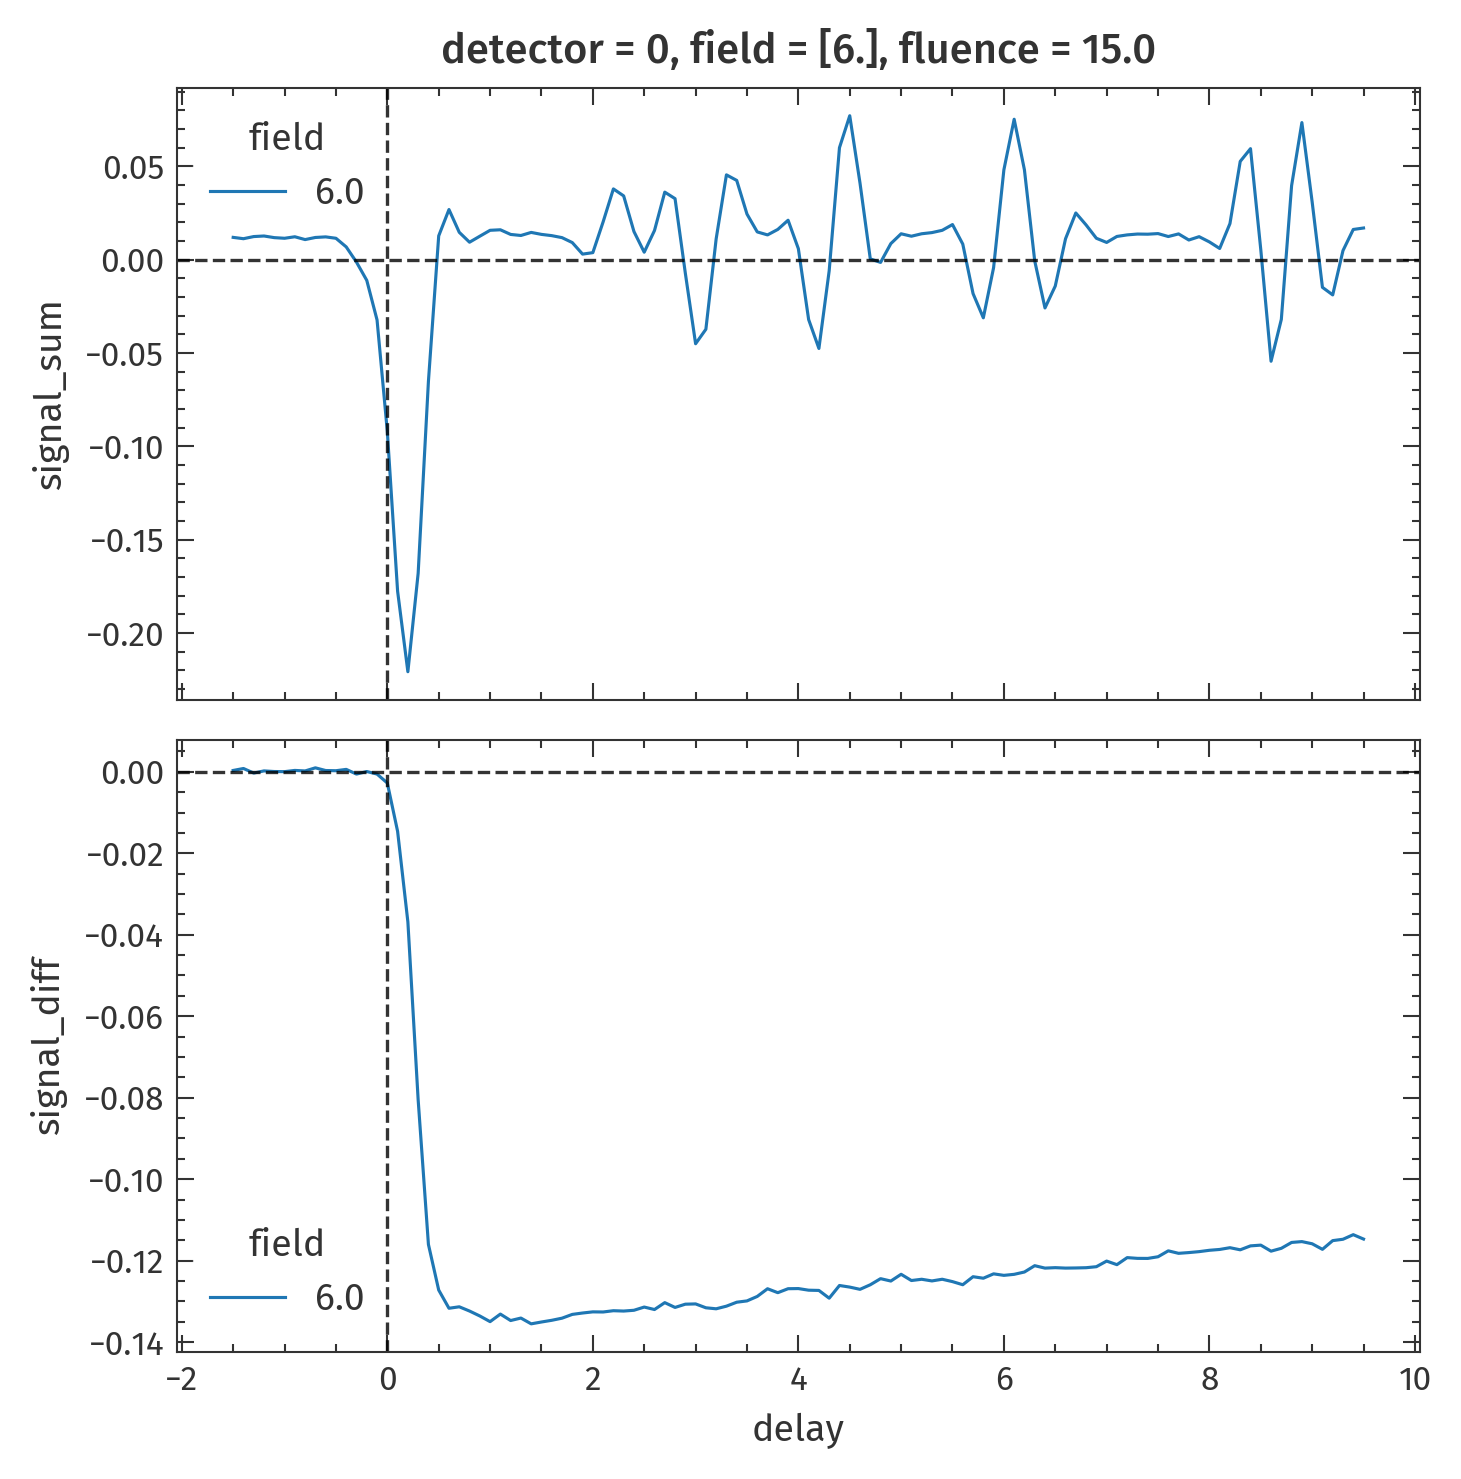

In [21]:
processed_dataset = prop.data.p0011
scan_param = processed_dataset.attrs['scan_param']
param1 = processed_dataset.attrs['param1']
param2 = processed_dataset.attrs['param2']

for param1_idx in range(len(processed_dataset[param1].values)):
    fig, ax = plt.subplots(2, 1, dpi=300, figsize=(5, 5), sharex=True)

    # Create selection dictionary
    sel_dict = {
        'detector': detector_idx,
        param1: param1_idx
    }

    # Plot sum (symmetric component)
    processed_dataset.signal_sum.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[0], add_legend=True)
    # Plot diff (antisymmetric component)
    processed_dataset.signal_diff.isel(**sel_dict).plot.line(
        x=scan_param, ax=ax[1], add_legend=True)

    ax[1].set_title(None)
    ax[0].set_xlabel(None)
    ax[0].set_ylabel('signal_sum')
    ax[1].set_ylabel('signal_diff')

    ax[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[0].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)
    ax[1].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.8)

    plt.tight_layout()
    plt.show()